# Finlora Fraud Risk-Scoring: SHAP Explainability

Ninth deliverable in the pipeline: explain *why* the model scores a
transaction as fraud-risky, not just *how well* it does so (already covered
in `notebooks/model_selection.ipynb` and the model-optimization notebooks).
Uses **SHAP** (SHapley Additive exPlanations) on the most up-to-date model,
`artifacts/precision_recall_balanced_model.joblib` (the PR-AUC-tuned
`HistGradientBoostingClassifier` from
`notebooks/model_optimization_precision_recall.ipynb`), evaluated on the
**validation set** -- the test set stays untouched, consistent with every
prior notebook.

SHAP attributes each prediction to its input features in a way that always
sums exactly to that prediction (in log-odds/margin space for this model) --
unlike the model's built-in `feature_importances_`, which only ranks features
globally, SHAP gives both:

- **Global explainability**: which features drive fraud risk *on average*,
  across the whole validation set.
- **Local explainability**: for one specific transaction, exactly which
  features pushed its score up or down, and by how much.

`shap.TreeExplainer` is used throughout -- it's exact (not approximated) and
fast for tree-ensemble models like this one.

**Contents**
1. Load the model, preprocessor, and validation data
2. Build the SHAP explainer
3. Global explainability: which features matter most?
4. Does SHAP agree with the EDA?
5. Dependence plots: how does each top feature push the score?
6. Local explainability: three individual transactions
7. Save explainability artifacts


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

ARTIFACTS_DIR = Path("../artifacts")
DATA_DIR = Path("../Data/splits")
OUT_DIR = Path("../eda")
OUT_DIR.mkdir(exist_ok=True)

LEGIT, FRAUD = "#2A6FDB", "#E63946"

## 1. Load the model, preprocessor, and validation data

In [2]:
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
model = joblib.load(ARTIFACTS_DIR / "precision_recall_balanced_model.joblib")
with open(ARTIFACTS_DIR / "feature_config.json") as f:
    feature_config = json.load(f)
with open(ARTIFACTS_DIR / "precision_recall_balance_summary.json") as f:
    balance_summary = json.load(f)

feature_columns = feature_config["feature_columns"]
target_column = feature_config["target_column"]
operating_threshold = balance_summary["closest_balance_point"]["threshold"]

print(f"Explaining: precision_recall_balanced_model.joblib (HistGradientBoostingClassifier)")
print(f"Operating threshold: {operating_threshold:.4f} "
      f"(precision={balance_summary['closest_balance_point']['precision']:.1%}, "
      f"recall={balance_summary['closest_balance_point']['recall']:.1%})")


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    hour_bins = [-1, 5, 11, 17, 23]
    hour_labels = ["Night", "Morning", "Afternoon", "Evening"]
    df["hour_bucket"] = pd.cut(df["hour_of_day"], bins=hour_bins, labels=hour_labels).astype(str)
    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    df["amount_log"] = np.log1p(df["amount"].clip(lower=0))
    df["velocity_flag"] = (df["transaction_velocity_1h"] >= 1).astype(int)
    return df


val = pd.read_csv(DATA_DIR / "val.csv")
val_fe = engineer_features(val)
X_val = val_fe[feature_columns]
y_val = val_fe[target_column]
X_val_processed = preprocessor.transform(X_val)

raw_feature_names = preprocessor.get_feature_names_out()
# "cat__account_type_Business" -> "account_type=Business"; "num__amount" -> "amount"
clean_feature_names = [
    n.replace("cat__", "").replace("num__", "").replace("_", "=", 1) if n.startswith("cat__")
    else n.replace("num__", "")
    for n in raw_feature_names
]

print("Processed validation matrix:", X_val_processed.shape)

Explaining: precision_recall_balanced_model.joblib (HistGradientBoostingClassifier)
Operating threshold: 0.9150 (precision=66.0%, recall=66.0%)


Processed validation matrix: (18900, 60)


## 2. Build the SHAP explainer

`shap.TreeExplainer` computes exact Shapley values for tree ensembles by
walking the trees directly, rather than approximating via sampling (as
`KernelExplainer` would need to for a black-box model) -- exact and fast
here, as shown by the timing.

In [3]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X_val_processed)
explanation.feature_names = clean_feature_names

print("SHAP values shape:", explanation.values.shape)
print("Base value (log-odds of fraud with no feature information):", explanation.base_values[0])

SHAP values shape: (18900, 60)
Base value (log-odds of fraud with no feature information): -1.6763255087403277


## 3. Global explainability: which features matter most?

The **beeswarm plot** shows every validation transaction as one dot per
feature: its position on the x-axis is that feature's SHAP contribution to
*that* transaction's score (right = pushes toward fraud, left = pushes toward
legitimate), and its color is the feature's own value (red = high, blue =
low). The **bar plot** collapses this to one global ranking: mean absolute
SHAP value per feature.

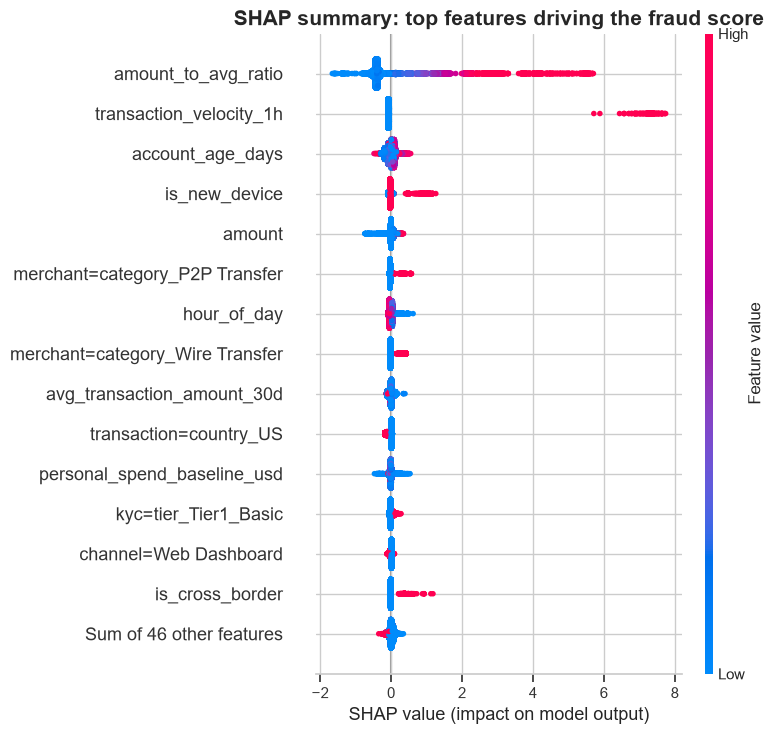

In [4]:
fig = plt.figure(figsize=(11, 9))
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title("SHAP summary: top features driving the fraud score", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

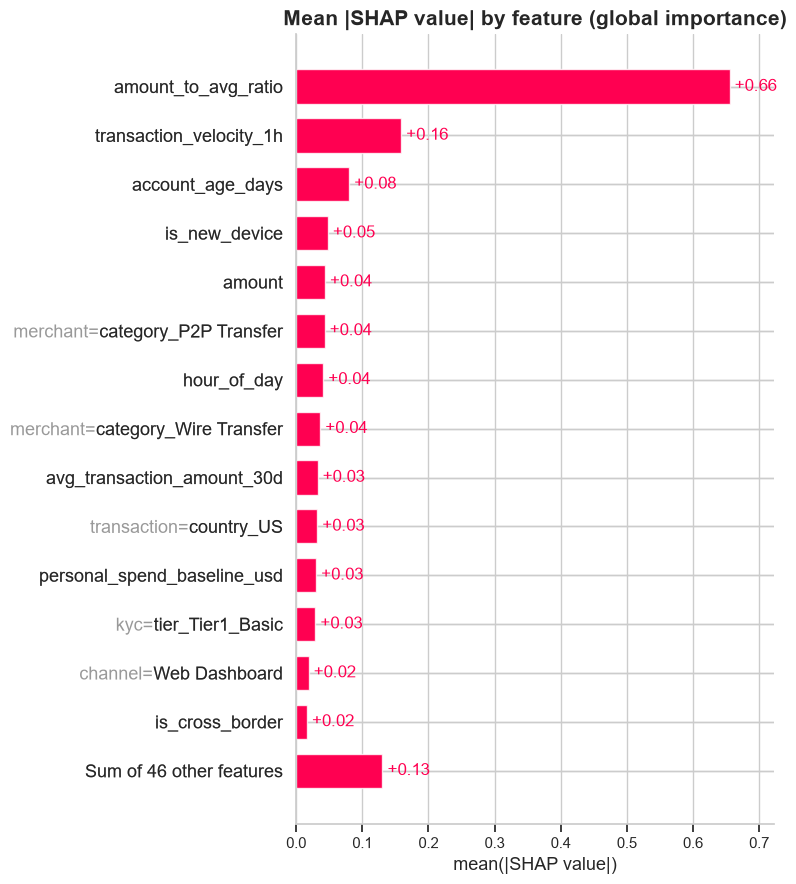

In [5]:
fig = plt.figure(figsize=(10, 8))
shap.plots.bar(explanation, max_display=15, show=False)
plt.title("Mean |SHAP value| by feature (global importance)", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Does SHAP agree with the EDA?

`notebooks/eda.ipynb` found `transaction_velocity_1h` (r = 0.58) and
`amount_to_avg_ratio` (r = 0.16) as the two strongest numeric correlates of
`is_fraud`, well ahead of everything else. SHAP's model-based ranking is
compared against that correlation-based ranking here -- a genuine cross-check,
not a foregone conclusion, since SHAP reflects what the *trained model*
actually uses, which can differ from raw correlation (e.g. if two correlated
features let the model substitute one for the other).

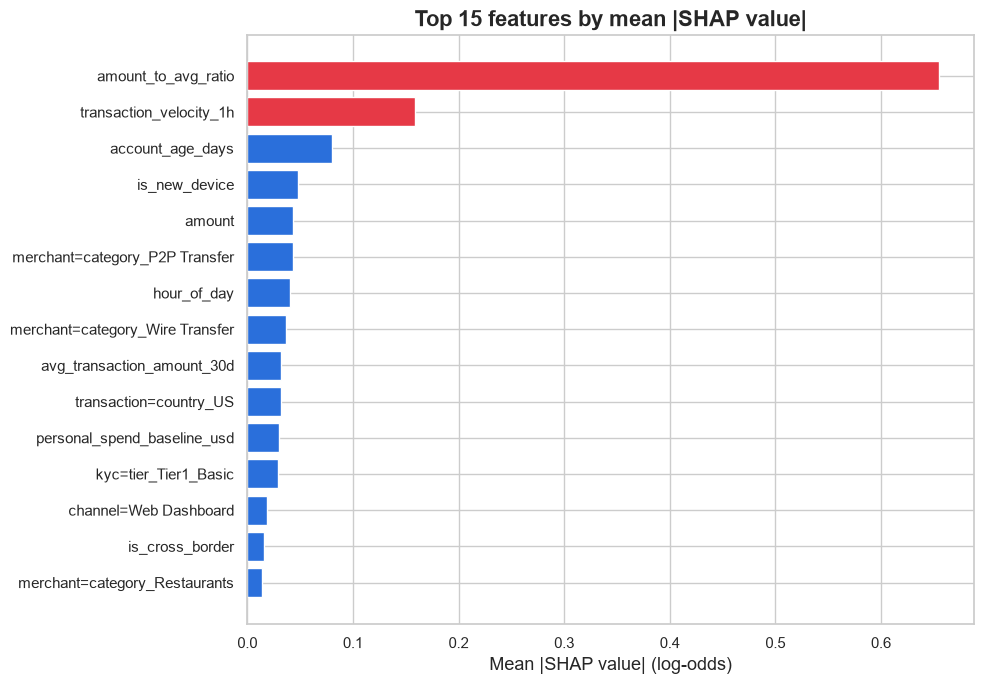

amount_to_avg_ratio                0.655309
transaction_velocity_1h            0.158563
account_age_days                   0.080048
is_new_device                      0.047724
amount                             0.043371
merchant=category_P2P Transfer     0.042907
hour_of_day                        0.040801
merchant=category_Wire Transfer    0.036272
avg_transaction_amount_30d         0.032280
transaction=country_US             0.031731
personal_spend_baseline_usd        0.030028
kyc=tier_Tier1_Basic               0.028853
channel=Web Dashboard              0.018757
is_cross_border                    0.016171
merchant=category_Restaurants      0.013839
dtype: float64

In [6]:
mean_abs_shap = pd.Series(
    np.abs(explanation.values).mean(axis=0), index=clean_feature_names
).sort_values(ascending=False)

top15 = mean_abs_shap.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
colors = [FRAUD if "velocity" in f or "ratio" in f else LEGIT for f in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel("Mean |SHAP value| (log-odds)")
ax.set_title("Top 15 features by mean |SHAP value|")
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

top15

**Finding:** SHAP agrees with the EDA on *which two features matter most* --
`amount_to_avg_ratio` and `transaction_velocity_1h` are, by a wide margin, the
top two -- but **disagrees on their order**. The EDA's raw correlation ranked
`transaction_velocity_1h` far ahead (r = 0.58 vs. r = 0.16), while the trained
model's SHAP values put `amount_to_avg_ratio` roughly **4x** higher (mean
|SHAP| 0.655 vs. 0.159). Two things explain the flip:

- `transaction_velocity_1h` is a near-binary signal (0 for ~99% of rows, 1-3
  otherwise) -- a single tree split captures nearly all of its information in
  one cut, so its *total* contribution across all trees is smaller even
  though it's extremely discriminating where it applies. Its engineered
  `velocity_flag` companion doesn't even place in the top 15 -- the model
  found `transaction_velocity_1h` alone sufficient and didn't need the
  redundant binary version.
- `amount_to_avg_ratio` is continuous and long-tailed, giving the model many
  different thresholds to split on across its trees, each contributing its
  own share of SHAP value -- so its influence *accumulates* across more of
  the ensemble than a near-binary feature's can.

This is a genuine, useful distinction: correlation measures raw statistical
association with the target, while SHAP measures how much the *trained
model* actually leans on a feature to produce its scores -- they usually
point the same direction (as they do here, on the top-2) but need not rank
identically.

## 5. Dependence plots: how does each top feature push the score?

A **scatter (dependence) plot** shows one feature's own value on the x-axis
against its SHAP contribution on the y-axis -- revealing not just *that* a
feature matters, but the *shape* of its effect (a threshold jump, a smooth
ramp, a U-shape, etc.), and its interaction color-coded by a second feature
SHAP finds most correlated with it.

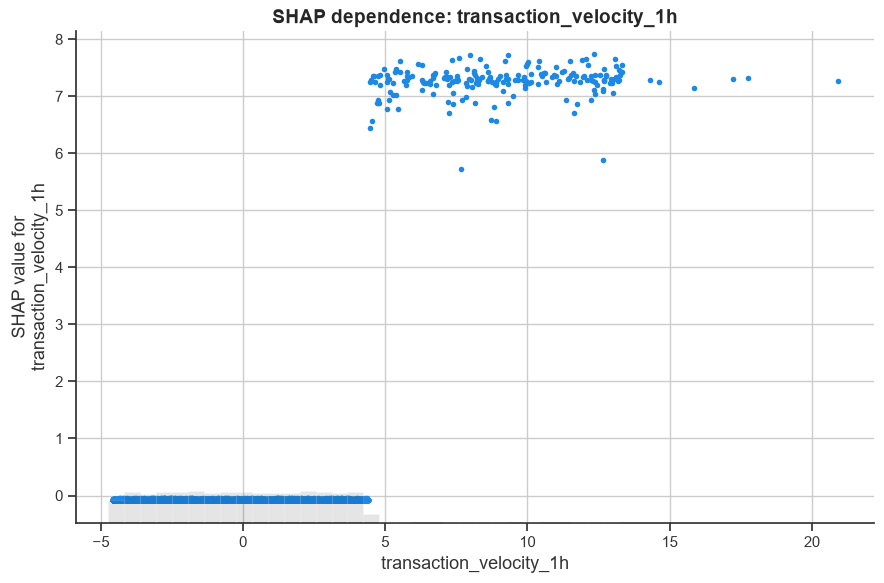

In [7]:
fig = plt.figure(figsize=(9, 6))
shap.plots.scatter(explanation[:, "transaction_velocity_1h"], show=False, ax=plt.gca())
plt.title("SHAP dependence: transaction_velocity_1h", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

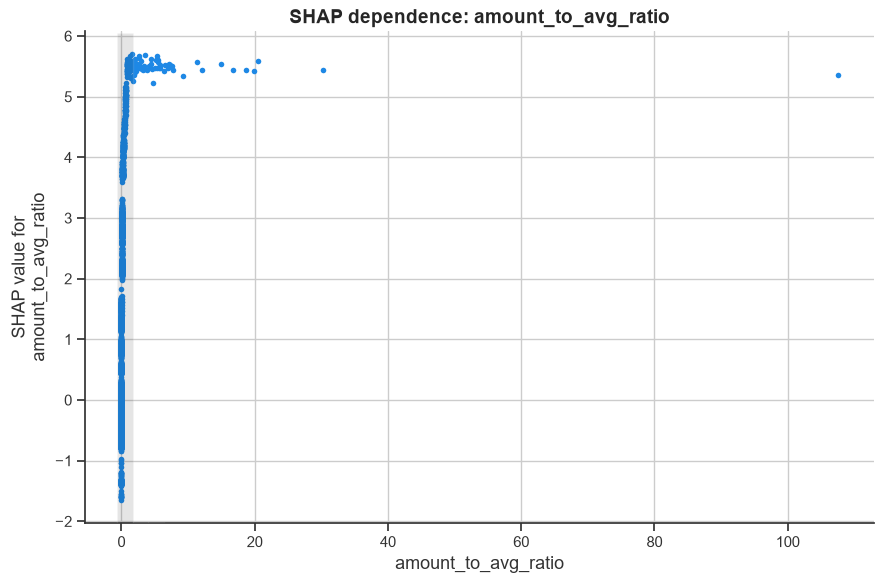

In [8]:
fig = plt.figure(figsize=(9, 6))
shap.plots.scatter(explanation[:, "amount_to_avg_ratio"], show=False, ax=plt.gca())
plt.title("SHAP dependence: amount_to_avg_ratio", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

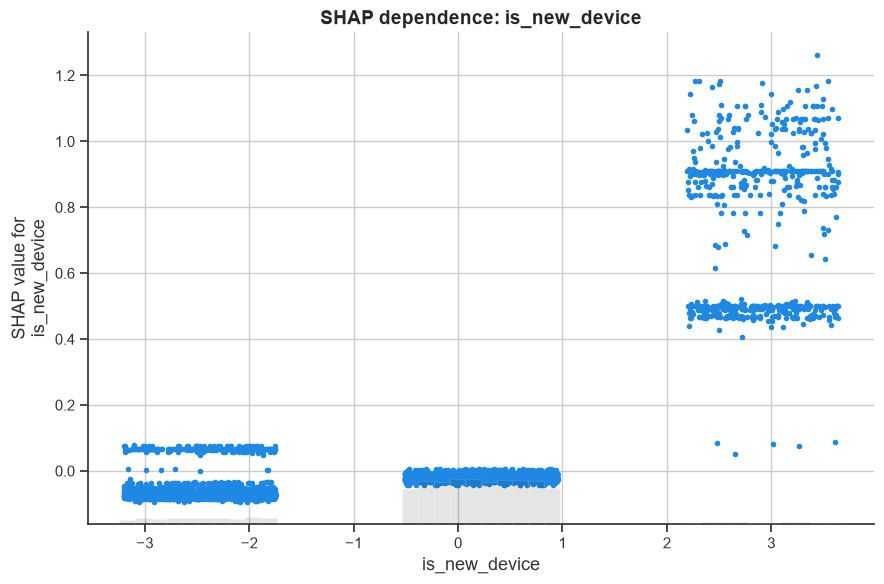

In [9]:
fig = plt.figure(figsize=(9, 6))
shap.plots.scatter(explanation[:, "is_new_device"], show=False, ax=plt.gca())
plt.title("SHAP dependence: is_new_device", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

**Finding:** `transaction_velocity_1h` shows a sharp step -- any repeat
transaction within the hour (value >= 1) jumps the SHAP contribution up
substantially, consistent with the EDA's ">400x gap" finding rather than a
smooth, proportional effect. `amount_to_avg_ratio` ramps up more gradually --
the further a transaction's amount sits above the account's own average, the
more it pushes the score toward fraud, with the effect leveling off at very
high ratios (the model has already seen enough evidence by then).

## 6. Local explainability: three individual transactions

One **true positive** (a fraud transaction the model correctly flags with
high confidence), one **false negative** (a fraud transaction the model
misses), and one **false positive** (a legitimate transaction the model
incorrectly flags) -- each a **waterfall plot** showing exactly which
features pushed that one prediction up or down from the base rate, and by
how much.

In [10]:
proba = model.predict_proba(X_val_processed)[:, 1]
preds = (proba >= operating_threshold).astype(int)

y_val_arr = y_val.values
tp_idx = np.where((y_val_arr == 1) & (preds == 1))[0]
fn_idx = np.where((y_val_arr == 1) & (preds == 0))[0]
fp_idx = np.where((y_val_arr == 0) & (preds == 1))[0]

# Pick the most confident example of each so the waterfall tells a clear story
example_tp = tp_idx[np.argmax(proba[tp_idx])]
example_fn = fn_idx[np.argmin(proba[fn_idx])]
example_fp = fp_idx[np.argmax(proba[fp_idx])]

for name, idx in [("True positive", example_tp), ("False negative", example_fn), ("False positive", example_fp)]:
    print(f"{name}: row {idx}, true label={y_val_arr[idx]}, predicted proba={proba[idx]:.4f}, "
          f"predicted label={preds[idx]}")

True positive: row 2129, true label=1, predicted proba=0.9987, predicted label=1
False negative: row 4458, true label=1, predicted proba=0.0686, predicted label=0
False positive: row 15044, true label=0, predicted proba=0.9964, predicted label=1


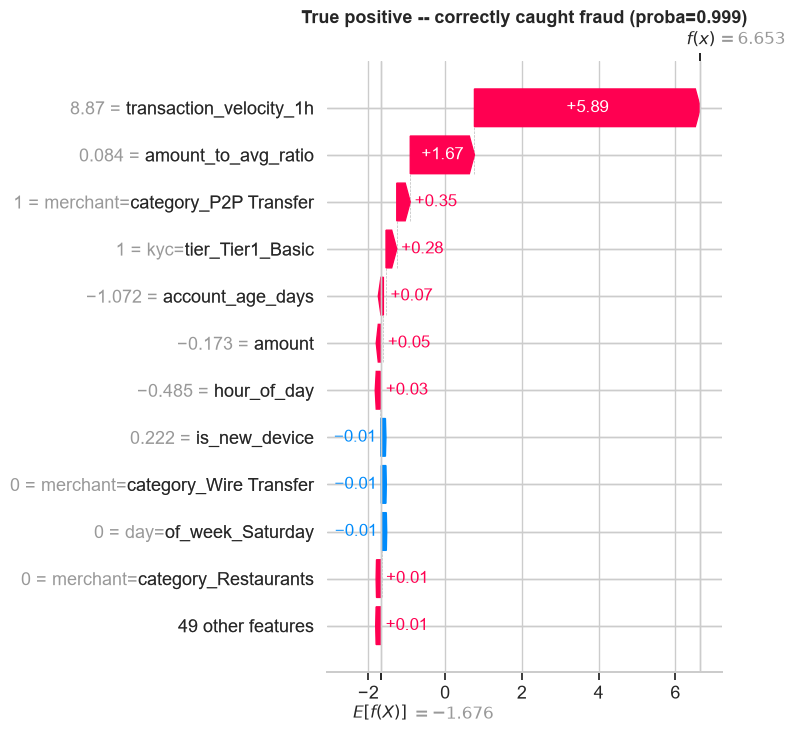

In [11]:
fig = plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation[example_tp], max_display=12, show=False)
plt.title(f"True positive -- correctly caught fraud (proba={proba[example_tp]:.3f})", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

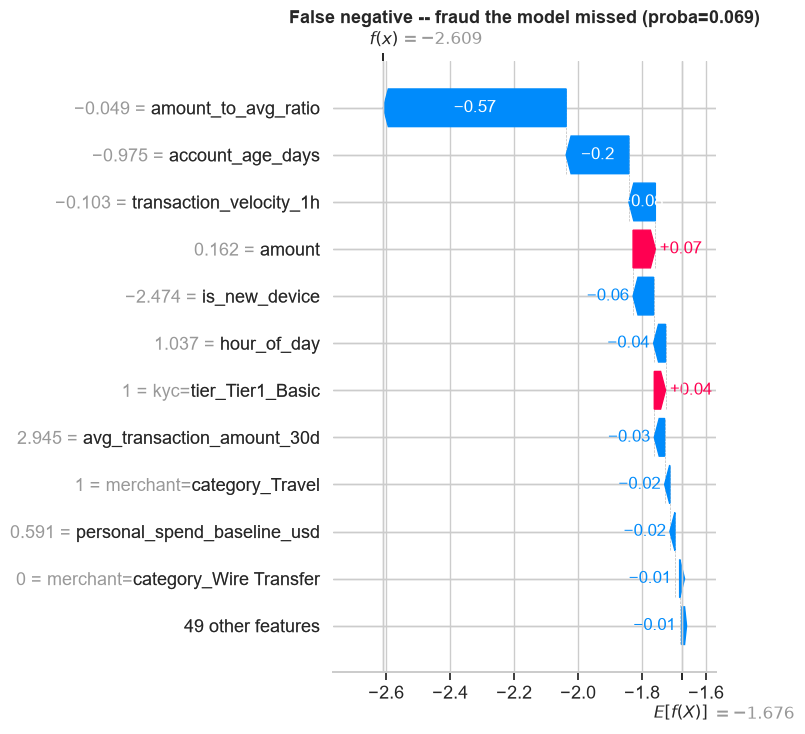

In [12]:
fig = plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation[example_fn], max_display=12, show=False)
plt.title(f"False negative -- fraud the model missed (proba={proba[example_fn]:.3f})", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

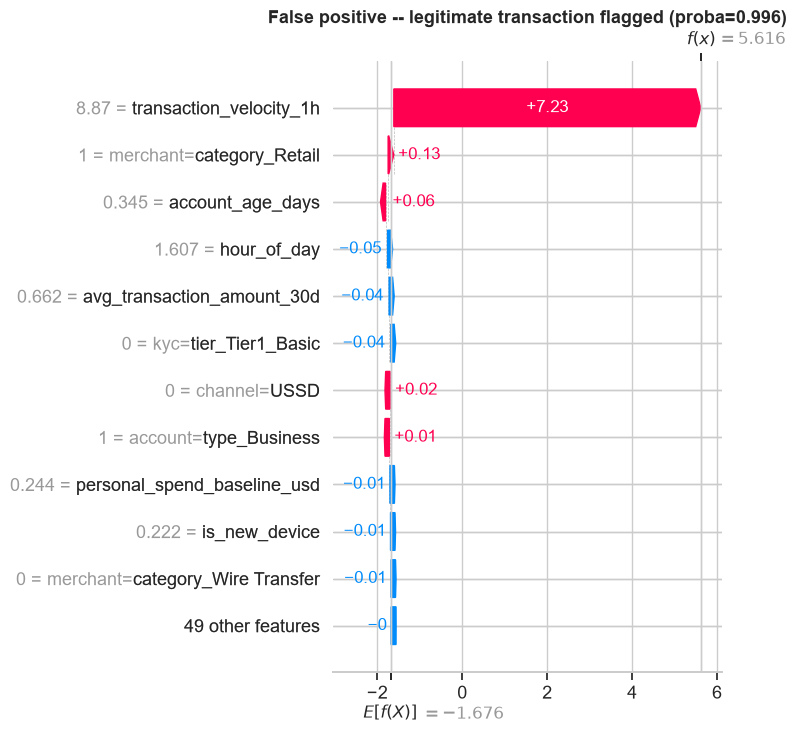

In [13]:
fig = plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation[example_fp], max_display=12, show=False)
plt.title(f"False positive -- legitimate transaction flagged (proba={proba[example_fp]:.3f})", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

**Reading these plots:** `E[f(x)]` at the bottom is the average model
output across the validation set (in log-odds); each row adds or subtracts
from it based on that transaction's own feature values; the final `f(x)` at
the top is that transaction's actual score. The **false negative** example is
the most informative failure mode to inspect: it shows which features *should
have* raised the score but didn't outweigh the features pulling it down --
useful for judging whether the miss reflects a genuinely ambiguous
transaction or a feature gap worth addressing.

## 7. Save explainability artifacts

The beeswarm and importance-bar figures are already saved to `eda/` above,
alongside the existing EDA plots. The global importance ranking is saved
separately so it can be referenced without re-running SHAP.

In [14]:
shap_importance_summary = {
    "explained_model": "precision_recall_balanced_model.joblib",
    "operating_threshold": operating_threshold,
    "mean_abs_shap_top15": mean_abs_shap.head(15).to_dict(),
    "example_indices": {
        "true_positive": int(example_tp),
        "false_negative": int(example_fn),
        "false_positive": int(example_fp),
    },
}
with open(ARTIFACTS_DIR / "shap_importance_summary.json", "w") as f:
    json.dump(shap_importance_summary, f, indent=2)

print("Saved:")
print(" ", OUT_DIR / "shap_beeswarm.png")
print(" ", OUT_DIR / "shap_importance_bar.png")
print(" ", ARTIFACTS_DIR / "shap_importance_summary.json")

Saved:
  ..\eda\shap_beeswarm.png
  ..\eda\shap_importance_bar.png
  ..\artifacts\shap_importance_summary.json


**Note:** the test set (`Data/splits/test.csv`) has not been read anywhere in
this notebook -- all SHAP values and examples come from the validation set,
consistent with every prior model notebook.